In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import os

from SNAP.snap.wrapper import TorchWrapper
from SNAP.snap.experiment import Experiment
from SNAP.snap.brainscore_data import get_neural_data
from SNAP.snap.models import get_model

activations_root = './activations/brainscore'
results_root = './ceph_spectral_cka'
os.makedirs(activations_root, exist_ok=True)
os.makedirs(results_root, exist_ok=True)

label_fontsize = 14

In [27]:
import torch
from src.spectral_cka import experiment, predict_cka, compute_self_overlap

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available() and False

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [28]:
def preprocess_activations(activations):
    activations = torch.tensor(activations)
    activations = activations.to(torch.float64)
    activations = activations.view(activations.size(0), -1)
    print(activations.size())
    # subtract mean
    activations = activations - activations.mean(dim=0, keepdim=True)
    # make it to float64 in case it's not
    activations = activations.to(torch.float64)
    return activations


def process_batch(model_wrapped, exp, batch_data):
    imgs, lbls = batch_data
    # Get activations for this batch
    activations = exp.get_activations([(imgs, lbls)])
    batch_acts = {key: val.cpu().numpy() for key, val in activations.items()}
    return batch_acts, imgs.cpu().numpy(), lbls.cpu().numpy()

In [ ]:
region_names = ['V1', 'V2',  # 'V4', 'IT'
                ]

model_names = [
    'alexnet', 'vgg11', 'vgg16', 'vgg19', 'resnet18', 'resnet50', 'resnet101', 'resnet152',
    'convnext_small', 'convnext_base', 'convnext_large',
    'cornet_r', 'cornet_z', 'cornet_rt', 'cornet_s',
    'vonenet_resnet50', 'vonenet_cornets', 'vonenet_alexnet',
    'efficientnet_b0', 'efficientnet_b4',
    'mobilenet_v2',
    'densenet121', 'densenet161', 'densenet169', 'densenet201',
    'wide_resnet50_2', 'wide_resnet101_2',
    'barlowtwins',
    # 'simclr_resnet50w1', 'simclr_resnet101',
    # 'moco_resnet50'
]

pooling = 'MaxPool_(1,1)'

In [30]:
for region in region_names:

    for model_name in model_names:
        print(f"region: {region}, model: {model_name}")
        filename = activations_root + f'/{region}_{model_name}_{pooling}_activations.npz'

        if os.path.exists(filename):
            print('Found activations', model_name, region)
            # data = np.load(filename, allow_pickle=True)
            # acts = data['acts'].tolist()
            # recs = data['recs']
            # imgs = data['imgs']
            # print(recs.shape, imgs.shape, {key: val.shape for key, val in acts.items()})
            continue

        else:
            data_loader_neural, images, labels = get_neural_data(region)
            # Get the model
            model_kwargs = {'name': model_name,
                            'pretrained': True,
                            'device': device}
            model, layers, identifier = get_model(**model_kwargs)
            model_wrapped = TorchWrapper(model, layers=layers, identifier=identifier, activation_pooling=pooling)
            exp = Experiment(model_wrapped, metric_fns=[], rand_proj_dim=None)

            # Process in batches
            all_acts = None
            all_imgs = []
            all_recs = []

            for batch_idx, batch in enumerate(data_loader_neural()):
                print(f"Processing batch {batch_idx}")

                # Process batch
                batch_acts, batch_imgs, batch_recs = process_batch(model_wrapped, exp, batch)

                # Initialize all_acts with the structure from first batch
                if all_acts is None:
                    all_acts = {key: [] for key in batch_acts.keys()}

                # Accumulate results
                for key in batch_acts:
                    all_acts[key].append(batch_acts[key])
                all_imgs.append(batch_imgs)
                all_recs.append(batch_recs)

                # Clear batch memory
                del batch_acts
                torch.cuda.empty_cache()
                gc.collect()

            # Combine all batches
            acts = {key: np.concatenate(all_acts[key]) for key in all_acts}
            imgs = np.concatenate(all_imgs)
            recs = np.concatenate(all_recs)

            np.savez(filename, acts=acts, imgs=imgs, recs=recs)

region: V1, model: alexnet
Found activations alexnet V1
region: V1, model: vgg11
Found activations vgg11 V1
region: V1, model: vgg16
Found activations vgg16 V1
region: V1, model: vgg19
Found activations vgg19 V1
region: V1, model: resnet18
Found activations resnet18 V1
region: V1, model: resnet50
Found activations resnet50 V1
region: V1, model: resnet101
Found activations resnet101 V1
region: V1, model: resnet152
Found activations resnet152 V1
region: V1, model: convnext_small
Found activations convnext_small V1
region: V1, model: convnext_base
Found activations convnext_base V1
region: V1, model: convnext_large
Found activations convnext_large V1
region: V1, model: cornet_r
Found activations cornet_r V1
region: V1, model: cornet_z
Found activations cornet_z V1
region: V1, model: cornet_rt
Found activations cornet_rt V1
region: V1, model: cornet_s
Found activations cornet_s V1
region: V1, model: vonenet_resnet50
Found activations vonenet_resnet50 V1
region: V1, model: vonenet_cornets
F

In [ ]:
def experiment_cka(neuron_size, cutoff, num_iterations, pooling, use_real_neuron):

    if use_real_neuron:
        suffix = '_real_neuron'
    else:
        suffix = ''

    results_dir = results_root + f"/cka_brain_score_results_N{neuron_size}_cutoff_{cutoff}_{pooling}{suffix}"

    os.makedirs(results_dir, exist_ok=True)

    for region in region_names:
        # Load and preprocess model2 data once per region
        filename = activations_root + f'/{region}_alexnet_{pooling}_activations.npz'
        data = np.load(filename, allow_pickle=True)

        brain_acts = preprocess_activations(data['recs']).cuda()

        for model_name in model_names:

            print(f"region: {region}, model: {model_name}")
            filename = activations_root + f'/{region}_{model_name}_{pooling}_activations.npz'
            results_filename = os.path.join(results_dir, f'{region}_{model_name}_results.pt')

            if not os.path.exists(filename):
                print(f"File not found: {filename}")
                continue

            if os.path.exists(results_filename):
                print(f"Results already exist for {region}_{model_name}")
                results_dict = torch.load(results_filename, weights_only=False)
                continue

            else:
                # raise ValueError(f"Results not found for {region}_{model_name}")
                data = np.load(filename, allow_pickle=True)
                model_acts = data['acts'].tolist()
                layer_names = list(model_acts.keys())

                results_dict = {}
                for layer_name in layer_names:
                    print(f"Processing layer: {layer_name}")
                    layer_acts = preprocess_activations(model_acts[layer_name]).cuda()

                    # Run the analysis
                    results = predict_cka(brain_acts, layer_acts, [neuron_size],
                                          cutoff=cutoff, num_iterations=num_iterations,
                                          use_real_neuron=use_real_neuron)

                    naive_mean_cka = np.asarray(results['cka_naive_mean'])
                    naive_std_cka = np.asarray(results['cka_naive_std'])
                    predicted_cka = np.asarray(results['predicted_cka_final'])
                    est_mean_cka = np.asarray(results['estimated_cka_final'])
                    est_std_cka = np.asarray(results['cka_est_std'])
                    est_sem_cka = est_std_cka / np.sqrt(num_iterations)

                    # Convert lists to numpy arrays for CCA
                    naive_mean_cca = np.asarray(results['cca_naive_mean'])
                    naive_std_cca = np.asarray(results['cca_naive_std'])
                    predicted_cca = np.asarray(results['predicted_cca_final'])
                    est_mean_cca = np.asarray(results['estimated_cca_final'])
                    est_std_cca = np.asarray(results['cca_est_std'])
                    est_sem_cca = est_std_cca / np.sqrt(num_iterations)

                    moment_cka_est_mean = np.asarray(results['moment_cka_est_mean'])
                    moment_cka_est_std = np.asarray(results['moment_cka_est_std'])
                    moment_cka_est_sem = moment_cka_est_std / np.sqrt(num_iterations)

                    results_dict[layer_name] = results

                    print(
                        f"region: {region}, model_name: {model_name}, Layer: {layer_name}\n "
                        f"Sample CCA: {naive_mean_cca.item():.4f}, Est CCA: {est_mean_cca.item():.4f},\n "
                        f"Sample CKA: {naive_mean_cka.item():.4f}, Est CKA: {est_mean_cka.item():.4f},\n "
                        f"Naive  CKA: {moment_cka_est_mean[0,0]:.4f}, Est CKA: {moment_cka_est_mean[0,-1]:.4f}"
                    )

                    del layer_acts
                    torch.cuda.empty_cache()
                    gc.collect()

                torch.save(results_dict, results_filename)

                print(f"Completed {model_name}")

In [32]:
neuron_size = 60
cutoff = None
num_iterations = 20
use_real_neuron = True

experiment_cka(neuron_size, cutoff, num_iterations, pooling, use_real_neuron)

torch.Size([135, 102])
region: V1, model: alexnet
Results already exist for V1_alexnet
region: V1, model: vgg11
Results already exist for V1_vgg11
region: V1, model: vgg16
Results already exist for V1_vgg16
region: V1, model: vgg19
Results already exist for V1_vgg19
region: V1, model: resnet18
Results already exist for V1_resnet18
region: V1, model: resnet50
Results already exist for V1_resnet50
region: V1, model: resnet101
Results already exist for V1_resnet101
region: V1, model: resnet152
Results already exist for V1_resnet152
region: V1, model: convnext_small
Results already exist for V1_convnext_small
region: V1, model: convnext_base
Results already exist for V1_convnext_base
region: V1, model: convnext_large
Results already exist for V1_convnext_large
region: V1, model: cornet_r
Results already exist for V1_cornet_r
region: V1, model: cornet_z
Results already exist for V1_cornet_z
region: V1, model: cornet_rt
Results already exist for V1_cornet_rt
region: V1, model: cornet_s
Resul

In [33]:
neuron_size = 60
cutoff = None
num_iterations = 20
use_real_neuron = False

experiment_cka(neuron_size, cutoff, num_iterations, pooling, use_real_neuron)

torch.Size([135, 102])
region: V1, model: alexnet
Results already exist for V1_alexnet
region: V1, model: vgg11
Results already exist for V1_vgg11
region: V1, model: vgg16
Results already exist for V1_vgg16
region: V1, model: vgg19
Results already exist for V1_vgg19
region: V1, model: resnet18
Results already exist for V1_resnet18
region: V1, model: resnet50
Results already exist for V1_resnet50
region: V1, model: resnet101
Results already exist for V1_resnet101
region: V1, model: resnet152
Results already exist for V1_resnet152
region: V1, model: convnext_small
Results already exist for V1_convnext_small
region: V1, model: convnext_base
Results already exist for V1_convnext_base
region: V1, model: convnext_large
Results already exist for V1_convnext_large
region: V1, model: cornet_r
Results already exist for V1_cornet_r
region: V1, model: cornet_z
Results already exist for V1_cornet_z
region: V1, model: cornet_rt
Results already exist for V1_cornet_rt
region: V1, model: cornet_s
Resul

In [34]:
region_names = ['V1', 'V2',  # 'V4', 'IT'
                ]

model_names = [
    'alexnet', 'vgg11', 'vgg16', 'vgg19', 'resnet18', 'resnet50', 'resnet101', 'resnet152',
    'convnext_small', 'convnext_base', 'convnext_large',
    'cornet_r', 'cornet_z', 'cornet_rt', 'cornet_s',
    'vonenet_resnet50', 'vonenet_cornets', 'vonenet_alexnet',
    'efficientnet_b0', 'efficientnet_b4',
    'mobilenet_v2',
    'densenet121', 'densenet161', 'densenet169', 'densenet201',
    'wide_resnet50_2', 'wide_resnet101_2',
    'barlowtwins',
    # 'simclr_resnet50w1', 'simclr_resnet101',
    # 'moco_resnet50'
]

neuron_size = 30
cutoff = None
num_iterations = 20
use_real_neuron = False
pooling = 'MaxPool_(1,1)'

if use_real_neuron:
    suffix = '_real_neuron'
else:
    suffix = ''

results_dir = results_root + f"/cka_brain_score_results_N{neuron_size}_cutoff_{cutoff}_{pooling}{suffix}"


keys = ['naive_cka_final', 'predicted_cka_final', 'estimated_cka_final',
        # 'M_pred_final', 'M_tilde_pred_final',
        'moment_cka_est_mean',
        'naive_cca_final', 'predicted_cca_final', 'estimated_cca_final',
        ]

# Dictionary to store all data
all_results = {
    'region': [],
    'model': [],
    'layer': [],
} | {key: [] for key in keys}

# Load all results
for region in region_names:
    for model_name in model_names:
        results_filename = os.path.join(results_dir, f'{region}_{model_name}_results.pt')

        if not os.path.exists(results_filename):
            print(f"File not found: {results_filename}")
            continue

        try:
            results_dict = torch.load(results_filename, weights_only=False)

            # Add each row to our dictionary
            for i, (layer_name, row) in enumerate(results_dict.items()):

                all_results['region'].append(region)
                all_results['model'].append(model_name)
                all_results['layer'].append(f"layer{i}")

                for key in keys:

                    val = np.array(row[key]).squeeze()
                    all_results[key].append(val)

            print(f"Loaded results for {region} - {model_name}")

        except FileNotFoundError:
            print(f"Error: Could not load file {results_filename}")
            continue
        except Exception as e:
            print(f"Error processing {results_filename}: {str(e)}")
            continue

# Save all combined results
if all_results['region']:  # If we have any results
    # Save everything
    combined_filename = os.path.join(results_dir, 'all_results_combined.npz')
    np.savez(combined_filename, **all_results)

    print(f"\nSaved combined results to: {combined_filename}")
    print(f"Total entries: {len(all_results['region'])}")

Loaded results for V1 - alexnet
Loaded results for V1 - vgg11
Loaded results for V1 - vgg16
Loaded results for V1 - vgg19
Loaded results for V1 - resnet18
Loaded results for V1 - resnet50
Loaded results for V1 - resnet101
Loaded results for V1 - resnet152
Loaded results for V1 - convnext_small
Loaded results for V1 - convnext_base
Loaded results for V1 - convnext_large
Loaded results for V1 - cornet_r
Loaded results for V1 - cornet_z
Loaded results for V1 - cornet_rt
Loaded results for V1 - cornet_s
Loaded results for V1 - vonenet_resnet50
Loaded results for V1 - vonenet_cornets
Loaded results for V1 - vonenet_alexnet
Loaded results for V1 - efficientnet_b0
Loaded results for V1 - efficientnet_b4
Loaded results for V1 - mobilenet_v2
Loaded results for V1 - densenet121
Loaded results for V1 - densenet161
Loaded results for V1 - densenet169
Loaded results for V1 - densenet201
Loaded results for V1 - wide_resnet50_2
Loaded results for V1 - wide_resnet101_2
Loaded results for V1 - barlowtw

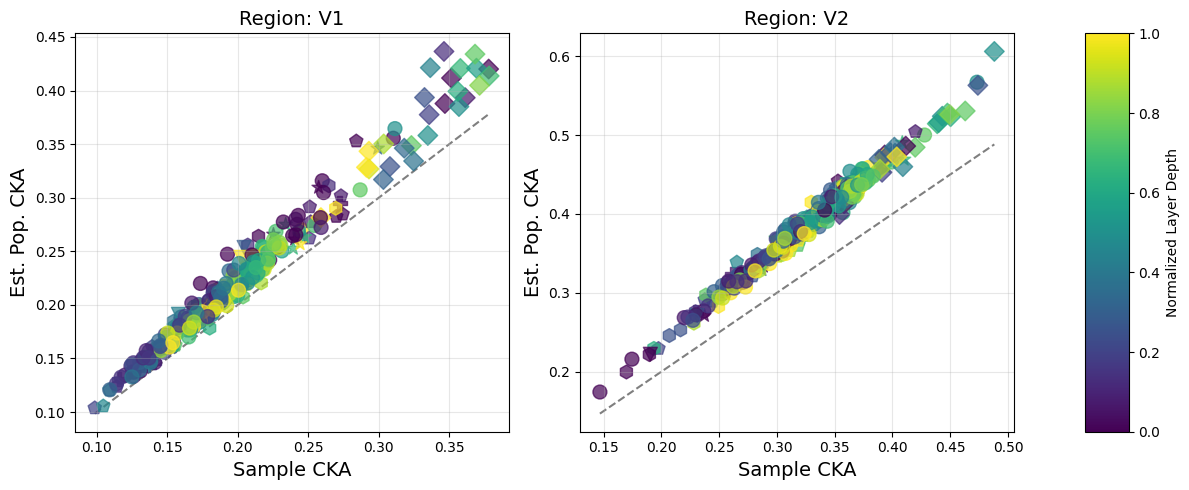

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_path = os.path.join(results_dir, 'all_results_combined.npz')
data = np.load(data_path, allow_pickle=True)

# Convert to more convenient format
results = {}
for key in data.keys():
    results[key] = data[key]

# Dictionary mapping model types to markers - use base model names
model_markers = {
    'alexnet': 'o',
    'vgg': 's',
    'resnet': '^',
    'convnext': 'p',
    'cornet': '*',
    'vonenet': 'D',
    'efficientnet': 'h',
    'mobilenet': 'v',
    'densenet': '<',
    'wide_resnet': '>',
    'barlowtwins': 'P',
    'simclr': 'X',
    # 'moco': '+'
}

# Create figure with 4 subplots and a colorbar
fig = plt.figure(figsize=(12, 5))
gs = plt.GridSpec(1, 3, width_ratios=[1, 1, 0.1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[:, 2])

axes = {'V1': ax1, 'V2': ax2}

# Create color map
colors = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=1)

# Create colorbar
sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])
plt.colorbar(sm, cax=cax, label='Normalized Layer Depth')

# Group models by base name first
base_models = {}
for model in np.unique(results['model']):
    base_name = model.split('_')[0]
    if base_name not in base_models:
        base_models[base_name] = []
    base_models[base_name].append(model)

# Dictionary to store one legend handle per base model
legend_handles = {}

for region in ['V1', 'V2']:
    ax = axes[region]
    region_mask = results['region'] == region

    # Get region-specific min/max
    region_samples = results['naive_cka_final'][region_mask]
    region_estimates = results['predicted_cka_final'][region_mask]
    x_min, x_max = np.min(region_samples), np.max(region_samples)
    y_min, y_max = np.min(region_estimates), np.max(region_estimates)

    # Add margin (5%)
    margin = 0.05
    x_lim = (x_min - margin*(x_max-x_min), x_max + margin*(x_max-x_min))
    y_lim = (y_min - margin*(y_max-y_min), y_max + margin*(y_max-y_min))

    # Plot diagonal first
    # ax.plot([x_min, x_max], [y_min, y_max], 'k--', alpha=0.5, zorder=0)
    # plot y=x
    ax.plot([x_min, x_max], [x_min, x_max], 'k--', alpha=0.5, zorder=0)

    # Plot points for each base model type
    for base_model, models in base_models.items():
        marker = model_markers.get(base_model, 'o')
        base_model_plotted = False

        for model in models:
            model_mask = results['model'] == model
            mask = region_mask & model_mask

            if not np.any(mask):
                continue

            layers = results['layer'][mask]

            # Extract layer indices
            layer_indices = [int(''.join(filter(str.isdigit, str(layer))))
                             if any(c.isdigit() for c in str(layer))
                             else 0
                             for layer in layers]

            if len(layer_indices) > 0:
                max_layer = max(layer_indices)
                normalized_depths = np.array(
                    layer_indices) / max_layer if max_layer > 0 else np.zeros_like(layer_indices)

                # Plot each layer
                scatter = ax.scatter(results['naive_cka_final'][mask],
                                     results['estimated_cka_final'][mask],
                                     marker=marker,
                                     c=[colors(d) for d in normalized_depths],
                                     label=base_model if not base_model_plotted else "",
                                     alpha=0.7,
                                     s=100)

                if not base_model_plotted:
                    legend_handles[base_model] = scatter
                    base_model_plotted = True

    ax.set_xlabel('Sample CKA', fontsize=label_fontsize)
    ax.set_ylabel('Est. Pop. CKA', fontsize=label_fontsize)
    ax.set_title(f'Region: {region}', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    # ax.set_xlim(x_lim)
    # ax.set_ylim(y_lim)

# Add single legend for all base models
handles = [legend_handles[base_model] for base_model in sorted(legend_handles.keys())]
labels = sorted(legend_handles.keys())
legend_elements = []
for base_model in sorted(model_markers.keys()):
    legend_elements.append(plt.Line2D([0], [0], marker=model_markers[base_model], color='w',
                                      markerfacecolor='gray', markersize=10, label=base_model))

# Add the manual legend
# fig.legend(handles=legend_elements, bbox_to_anchor=(0.85, 0.4), ncols=2)

plt.tight_layout()
plt.savefig('./figures/cka_scatter_brainscore_N30.pdf')
plt.show()

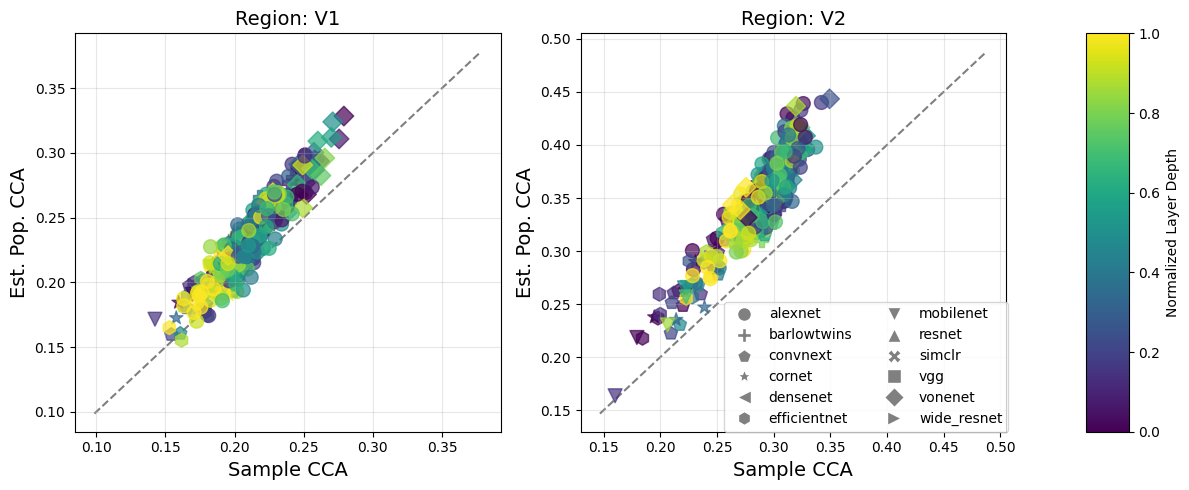

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_path = os.path.join(results_dir, 'all_results_combined.npz')
data = np.load(data_path, allow_pickle=True)

# Convert to more convenient format
results = {}
for key in data.keys():
    results[key] = data[key]

# Dictionary mapping model types to markers - use base model names
model_markers = {
    'alexnet': 'o',
    'vgg': 's',
    'resnet': '^',
    'convnext': 'p',
    'cornet': '*',
    'vonenet': 'D',
    'efficientnet': 'h',
    'mobilenet': 'v',
    'densenet': '<',
    'wide_resnet': '>',
    'barlowtwins': 'P',
    'simclr': 'X',
    # 'moco': '+'
}

# Create figure with 4 subplots and a colorbar
fig = plt.figure(figsize=(12, 5))
gs = plt.GridSpec(1, 3, width_ratios=[1, 1, 0.1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[:, 2])

axes = {'V1': ax1, 'V2': ax2}

# Create color map
colors = plt.cm.viridis
norm = plt.Normalize(vmin=0, vmax=1)

# Create colorbar
sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])
plt.colorbar(sm, cax=cax, label='Normalized Layer Depth')

# Group models by base name first
base_models = {}
for model in np.unique(results['model']):
    base_name = model.split('_')[0]
    if base_name not in base_models:
        base_models[base_name] = []
    base_models[base_name].append(model)

# Dictionary to store one legend handle per base model
legend_handles = {}

for region in ['V1', 'V2']:
    ax = axes[region]
    region_mask = results['region'] == region

    # Get region-specific min/max
    region_samples = results['naive_cka_final'][region_mask]
    region_estimates = results['predicted_cka_final'][region_mask]
    x_min, x_max = np.min(region_samples), np.max(region_samples)
    y_min, y_max = np.min(region_estimates), np.max(region_estimates)

    # Add margin (5%)
    margin = 0.05
    x_lim = (x_min - margin*(x_max-x_min), x_max + margin*(x_max-x_min))
    y_lim = (y_min - margin*(y_max-y_min), y_max + margin*(y_max-y_min))

    # Plot diagonal first
    # ax.plot([x_min, x_max], [y_min, y_max], 'k--', alpha=0.5, zorder=0)
    # plot y=x
    ax.plot([x_min, x_max], [x_min, x_max], 'k--', alpha=0.5, zorder=0)

    # Plot points for each base model type
    for base_model, models in base_models.items():
        marker = model_markers.get(base_model, 'o')
        base_model_plotted = False

        for model in models:
            model_mask = results['model'] == model
            mask = region_mask & model_mask

            if not np.any(mask):
                continue

            layers = results['layer'][mask]

            # Extract layer indices
            layer_indices = [int(''.join(filter(str.isdigit, str(layer))))
                             if any(c.isdigit() for c in str(layer))
                             else 0
                             for layer in layers]

            if len(layer_indices) > 0:
                max_layer = max(layer_indices)
                normalized_depths = np.array(
                    layer_indices) / max_layer if max_layer > 0 else np.zeros_like(layer_indices)

                # Plot each layer
                scatter = ax.scatter(results['naive_cca_final'][mask],
                                     results['estimated_cca_final'][mask],
                                     marker=marker,
                                     c=[colors(d) for d in normalized_depths],
                                     label=base_model if not base_model_plotted else "",
                                     alpha=0.7,
                                     s=100)

                if not base_model_plotted:
                    legend_handles[base_model] = scatter
                    base_model_plotted = True

    ax.set_xlabel('Sample CCA', fontsize=label_fontsize)
    ax.set_ylabel('Est. Pop. CCA', fontsize=label_fontsize)
    ax.set_title(f'Region: {region}', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    # ax.set_xlim(x_lim)
    # ax.set_ylim(y_lim)

# Add single legend for all base models
handles = [legend_handles[base_model] for base_model in sorted(legend_handles.keys())]
labels = sorted(legend_handles.keys())
legend_elements = []
for base_model in sorted(model_markers.keys()):
    legend_elements.append(plt.Line2D([0], [0], marker=model_markers[base_model], color='w',
                                      markerfacecolor='gray', markersize=10, label=base_model))

# Add the manual legend
fig.legend(handles=legend_elements, bbox_to_anchor=(0.85, 0.4), ncols=2)

plt.tight_layout()
plt.savefig('./figures/cca_scatter_brainscore_N30.pdf')
plt.show()